In [1]:
import torch
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn

from utils.Plotter.index import Plotter
from utils.index import *

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versao do PyTorch
pd.set_option('display.max_columns', None)

2.7.1+cu118


# HISTÓRICO DE TREINAMENTO

In [3]:
models = [path for path in os.listdir('Backup/') if path.startswith('model_')]
models

['model_2', 'model_5', 'model_1', 'model_3', 'model_4']

In [4]:
df = []

for backup in models:
    path = f'Backup/{backup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    if 'trainer' not in file:
        continue

    info = {}
    for key, value in file.items():
        info.update({k: v for k, v in value.items() if not isinstance(v, (dict, list))})

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df = df.loc[df.id >= 3]  # model_2 usou o split antigo (nao estratificado), metricas nao comparaveis
df.head()

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,dataset,network,img_size,n_aug,lr,score_threshold,nms_threshold,val_size,test_size,classes,channels,green,red,yellow,mean,id
2,model_3,sum,plateau,50,4,0.913382,0.927484,Aquisition,fasterrcnn,512,1,0.0001,0.5,0.3,0.1,0.1,4,3,0.901573,0.960840,0.922397,0.928270,3
3,model_4,boxes,plateau,50,4,0.917976,0.923371,Aquisition,fasterrcnn,512,1,0.0001,0.5,0.3,0.1,0.1,4,3,0.908328,0.955842,0.907357,0.923842,4
1,model_5,classifier,plateau,50,4,0.902201,0.865597,Aquisition,fasterrcnn,512,1,0.0001,0.5,0.3,0.1,0.1,4,3,0.816223,0.904995,0.875443,0.865554,5


# ANÁLISE DE VARIAÇÕES

target: loss | fixed: {'network': 'fasterrcnn', 'lr': 0.0001, 'img_size': 512, 'n_aug': 1, 'batch_size': 4, 'scheduler': 'plateau', 'score_threshold': 0.5}


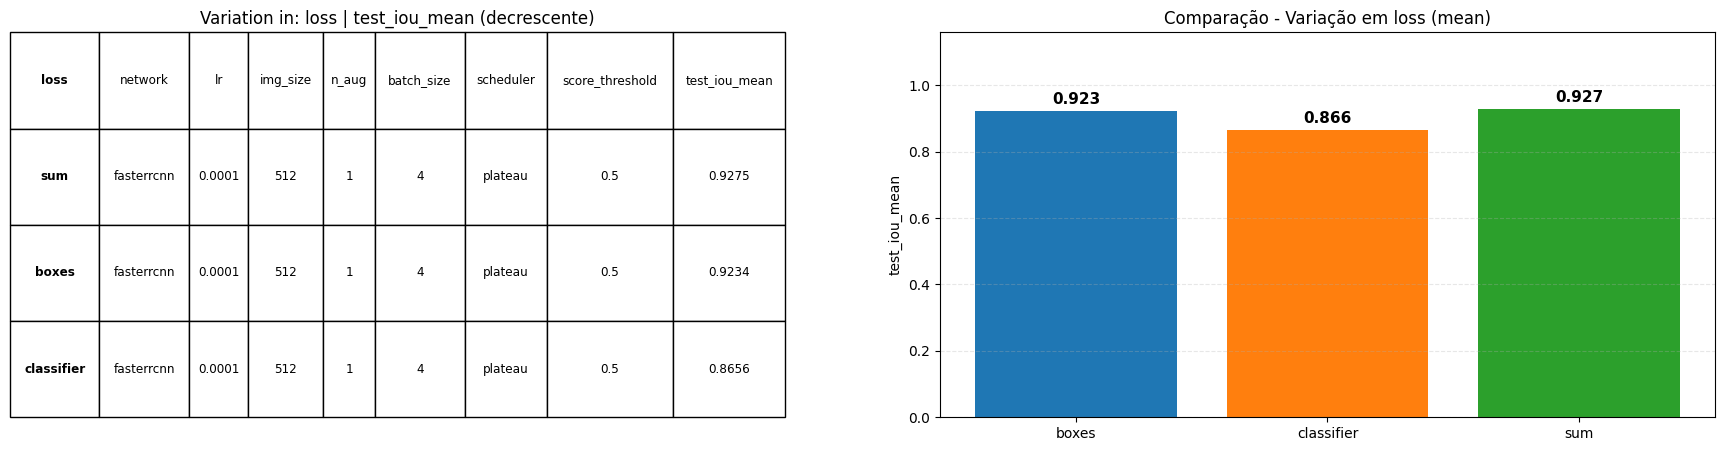

In [5]:
class VariationAnalysis:
    MODES = ('min', 'max', 'mean', 'std')

    def __init__(self, df, variations, id=None, metric='test_iou', mode='max', asc=False, max_str_len=25):
        self.df = df.copy()
        self.variations = [v for v in variations if v in self.df.columns]
        self.id = id if id in self.df.columns else None
        self.metric = metric
        self.mode = mode
        self.asc = asc
        self.max_str_len = max_str_len
        self.metric_label = f'{metric}_{mode}'
        self._clean()

    def _clean(self):
        self.df[self.metric] = pd.to_numeric(self.df[self.metric], errors='coerce')
        self.df = self.df.dropna(subset=[self.metric])

        for col in self.variations:
            numeric = pd.to_numeric(self.df[col], errors='coerce')
            if numeric.notna().sum() == self.df[col].notna().sum():
                self.df[col] = numeric
            else:
                self.df[col] = self.df[col].astype(str)

        if self.id:
            self.df[self.id] = self.df[self.id].astype(str)

    def _aggregate(self, group, var):
        gb = group.groupby(var, dropna=False)[self.metric]
        agg = gb.agg(self.mode).rename(self.metric_label).reset_index()

        if self.id and self.mode in ('min', 'max'):
            idx = gb.idxmin() if self.mode == 'min' else gb.idxmax()
            agg[self.id] = group.loc[idx.values, self.id].values

        return agg[agg[self.metric_label].notna()]

    def _build_table(self, agg, fixed_dict):
        table = agg.sort_values(self.metric_label, ascending=self.asc, kind='stable').copy()
        table[self.metric_label] = table[self.metric_label].round(4)

        for col, val in fixed_dict.items():
            table[col] = val

        cols = [c for c in self.variations if c in table.columns]
        if self.id and self.id in table.columns:
            cols.append(self.id)
        return table[cols + [self.metric_label]]

    def _format(self, table):
        show = table.copy()
        for col in show.columns:
            if col == self.id:
                show[col] = show[col].map(os.path.basename)
            show[col] = show[col].astype(str).str.slice(0, self.max_str_len)
        return show

    def _draw_table(self, ax, table, title, bold_col=None):
        ax.axis('off')
        show = self._format(table)

        char_widths = [max(len(str(c)), int(show[c].str.len().max())) + 2
                       for c in show.columns]
        col_widths = [w / sum(char_widths) for w in char_widths]

        fig_w, fig_h = ax.figure.get_size_inches()
        pos = ax.get_position()
        avail_w_pt = fig_w * pos.width * 72
        avail_h_pt = fig_h * pos.height * 72

        fit_w = avail_w_pt / (sum(char_widths) * 0.62)
        fit_h = avail_h_pt / (len(show) + 1) * 0.55
        fontsize = max(6, min(14, fit_w, fit_h))

        tbl = ax.table(cellText=show.values, colLabels=show.columns, colWidths=col_widths, loc='center', cellLoc='center', bbox=[0, 0, 1, 1])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(fontsize)

        if bold_col in show.columns:
            col_idx = show.columns.get_loc(bold_col)
            for (row, col), cell in tbl.get_celld().items():
                if col == col_idx:
                    cell.set_text_props(fontweight='bold')

        ax.set_title(title)

    def plot(self):
        for var in self.variations:
            fixed_cols = [c for c in self.variations if c != var]
            groups = (self.df.groupby(fixed_cols, dropna=False)
                      if fixed_cols else [((), self.df)])

            for _, group in groups:
                if group[var].nunique(dropna=False) <= 1:
                    continue

                fixed_dict = group.iloc[0][fixed_cols].to_dict() if fixed_cols else {}
                print(f'target: {var} | fixed: {fixed_dict}')

                agg = self._aggregate(group, var)
                if agg.empty:
                    continue

                table = self._build_table(agg, fixed_dict)

                chart = agg.sort_values(var, kind='stable')
                values = dict(zip(chart[var].astype(str), chart[self.metric_label]))

                vmin, vmax = min(values.values()), max(values.values())
                top = vmax * 1.25 if vmax > 0 else vmax + abs(vmax) * 0.25 + 1e-6
                bottom = min(0.0, vmin * 1.25)

                fig = plt.figure(figsize=(22, max(5, min(20, len(table) * 0.5 + 2))))

                ordem = 'crescente' if self.asc else 'decrescente'
                ax1 = fig.add_subplot(1, 2, 1)
                self._draw_table(ax1, table,
                                 f'Variation in: {var} | {self.metric_label} ({ordem})',
                                 bold_col=var)

                fig.add_subplot(1, 2, 2)
                title = f'Comparação - Variação em {var} ({self.mode})'
                try:
                    Plotter(values, limits=(bottom, top), title=title)
                except NameError:
                    bars = plt.bar(list(values.keys()), list(values.values()))
                    plt.bar_label(bars, fmt='%.3f')
                    plt.ylim(bottom, top)
                    plt.xticks(rotation=30)
                    plt.title(title)
                plt.ylabel(self.metric_label)
                plt.show()


variations = ['loss', 'network', 'lr', 'img_size', 'n_aug', 'batch_size', 'scheduler', 'score_threshold']
analysis = VariationAnalysis(df, variations, id='path', metric='test_iou', mode='mean', asc=False)
analysis.plot()

### Ranking

In [6]:
cols = ['path', 'loss', 'network', 'img_size', 'n_aug', 'lr', 'val_iou', 'green', 'red', 'yellow', 'test_iou']
cols = [c for c in cols if c in df.columns]
df[cols].sort_values('test_iou', ascending=False).reset_index(drop=True)

,path,loss,network,img_size,n_aug,lr,val_iou,green,red,yellow,test_iou
0,model_3,sum,fasterrcnn,512,1,0.0001,0.913382,0.901573,0.960840,0.922397,0.927484
1,model_4,boxes,fasterrcnn,512,1,0.0001,0.917976,0.908328,0.955842,0.907357,0.923371
2,model_5,classifier,fasterrcnn,512,1,0.0001,0.902201,0.816223,0.904995,0.875443,0.865597
